# **Malaria Detection**

## <b>Problem Definition</b>
**The context:** Why is this problem important to solve?<br>
**The objectives:** What is the intended goal?<br>
**The key questions:** What are the key questions that need to be answered?<br>
**The problem formulation:** What is it that we are trying to solve using data science?

## <b>Data Description </b>

There are a total of 24,958 train and 2,600 test images (colored) that we have taken from microscopic images. These images are of the following categories:<br>


**Parasitized:** The parasitized cells contain the Plasmodium parasite which causes malaria<br>
**Uninfected:** The uninfected cells are free of the Plasmodium parasites<br>


### <b> Mount the Drive

from google.colab import drive
drive.mount('/content/drive')

### <b>Loading libraries</b>

In [1]:
# reading libraries
import os
import cv2

# data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# warnings
import warnings
warnings.filterwarnings('ignore')

### <b>Let us load the data</b>

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same to your Google Drive. Then unzip the folder.

In [2]:
# !unzip "/content/drive/MyDrive/cell_images.zip" -d "/content/drive/MyDrive/cell_images_unzipped/"

The extracted folder has different folders for train and test data will contain the different sizes of images for parasitized and uninfected cells within the respective folder name.

The size of all images must be the same and should be converted to 4D arrays so that they can be used as an input for the convolutional neural network. Also, we need to create the labels for both types of images to be able to train and test the model.

Let's do the same for the training data first and then we will use the same code for the test data as well.

In [3]:
# declaring path to the folder containing the images
path_to_folder = '/kaggle/input/datasets/owentamunogilbert/cell-images/cell_images/train'
categories = ["uninfected", "parasitized"]
img_size = 150                            # image resize dimension

#
train_data = []


# let's create a function to load data from folders and resize

def load_train_data():
 # for loop to map and resize images
  for category in categories:
    path = os.path.join(path_to_folder, category)
    class_num = category

    for img in os.listdir(path):         # lists the items in path
      if img.endswith('.png'):           # ensure we deal with only images

        img_array = cv2.imread(os.path.join(path,img))       # read image

        new_array = cv2.resize(img_array, (img_size, img_size))         # resize image

        train_data.append([new_array, class_num])               # append images to image list

load_train_data()


In [4]:
# declaring path to the folder containing the images
path_to_folder_test = '/kaggle/input/datasets/owentamunogilbert/cell-images/cell_images/test'
categories = ["uninfected", "parasitized"]
img_size = 150                            # image resize dimension

#
test_data = []


# let's create a function to load data from folders and resize

def load_test_data():
 # for loop to map and resize images
  for category in categories:
    path = os.path.join(path_to_folder_test, category)
    class_num = category

    for img in os.listdir(path):         # lists the items in path
      if img.endswith('.png'):           # ensure we deal with only images

        img_array = cv2.imread(os.path.join(path,img))       # read image

        new_array = cv2.resize(img_array, (img_size, img_size))         # resize image

        test_data.append([new_array, class_num])               # append images to image list

load_test_data()

In [5]:
x_train = []
y_train = []

np.random.shuffle(train_data)
print("loading the train data! ...")
for features, label in train_data:                                          # Iterating over the training data which is generated from the create_training_data() function
    x_train.append(features)                                                   # Appending images into X_train
    y_train.append(label)                        # x is images and y is labels

print("loading the test data! ...")
x_test = []
y_test = []

np.random.shuffle(test_data)                                                # Shuffling data to reduce variance and making sure that model remains general and overfit less
for features, label in test_data:                                           # Iterating over the training data which is generated from the create_testing_data() function
    x_test.append(features)                                                    # Appending images into X_test
    y_test.append(label)

print("Loading executed!!!")

loading the train data! ...
loading the test data! ...
Loading executed!!!


### <b> Check the shape of train and test images

In [6]:
x_train = np.array(x_train)
x_test = np.array(x_test)

print(f"Train data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

print("\nThis shows they are 4D images")

Train data shape: (24958, 150, 150, 3)
Test data shape: (2600, 150, 150, 3)

This shows they are 4D images


### <b> Check the shape of train and test labels

In [7]:
y_train = pd.DataFrame(y_train, columns = ["Label"], dtype = object)
y_test = pd.DataFrame(y_test, columns = ["Label"], dtype = object)

print(f"There are {y_train.shape} labels in train data \n")
print(f"and {y_test.shape} labels for test data")

There are (24958, 1) labels in train data 

and (2600, 1) labels for test data


#### <b> Observations and insights: _____


### <b>Check the minimum and maximum range of pixel values for train and test images

In [8]:
print(f"Train images min value: {x_train.min()}")
print(f"Train images max value: {x_train.max()}")

print(f"\nTest images min value: {x_test.min()}")
print(f"Test images max value: {x_test.max()}")

Train images min value: 0
Train images max value: 255

Test images min value: 0
Test images max value: 255


#### <b> Observations and insights: _____



### <b> Count the number of values in both uninfected and parasitized

In [9]:
# counting the number of parasitized and uninfected cells

train_count = y_train["Label"].value_counts()                # bincount does a value count of unique values
test_count = y_test["Label"].value_counts()

print(f"Uninfected train cells are {train_count[0]}, and {train_count[1]} infected cells")
print(f"\nUninfected test cells are: {test_count[0]}, infected are {test_count[1]}")

Uninfected train cells are 12582, and 12376 infected cells

Uninfected test cells are: 1300, infected are 1300


### <b>Normalize the images

In [10]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Normalized Training Min:", x_train.min(), "| Max:", x_train.max())
print("Normalized Testing Min:", x_test.min(), "| Max:", x_test.max())

Normalized Training Min: 0.0 | Max: 1.0
Normalized Testing Min: 0.0 | Max: 1.0


#### <b> Observations and insights: _____

### <b> Plot to check if the data is balanced

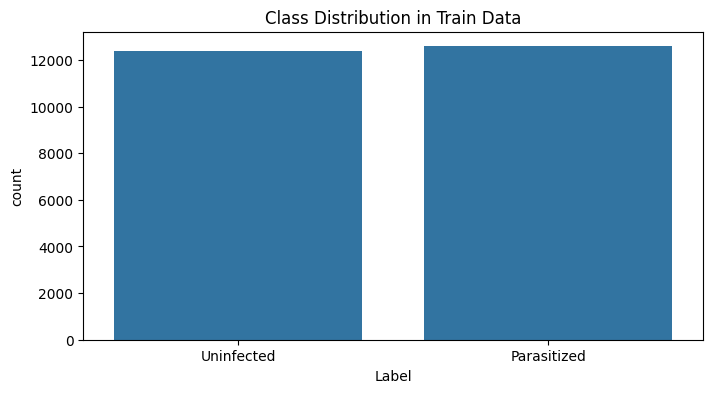

In [11]:
plt.figure(figsize=(8,4))                              # create a figure for plotting
sns.countplot(x=y_train["Label"])                                # count plot of infected and uninfected
plt.title("Class Distribution in Train Data")
plt.xticks([0,1], ["Uninfected", "Parasitized"])       # mapping label to a text
plt.show()

#### <b> Observations and insights: _____

### <b>Data Exploration</b>
Let's visualize the images from the train data

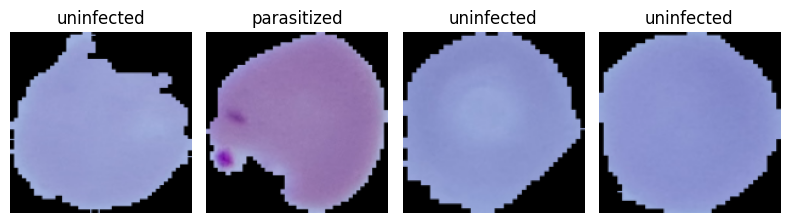

In [12]:
plt.figure(figsize=(8, 4))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(y_train.loc[i,"Label"])
    plt.axis('off')
plt.tight_layout()
plt.show()

#### <b> Observations and insights: _____

### <b> Visualize the images with subplot(6, 6) and figsize = (12, 12)

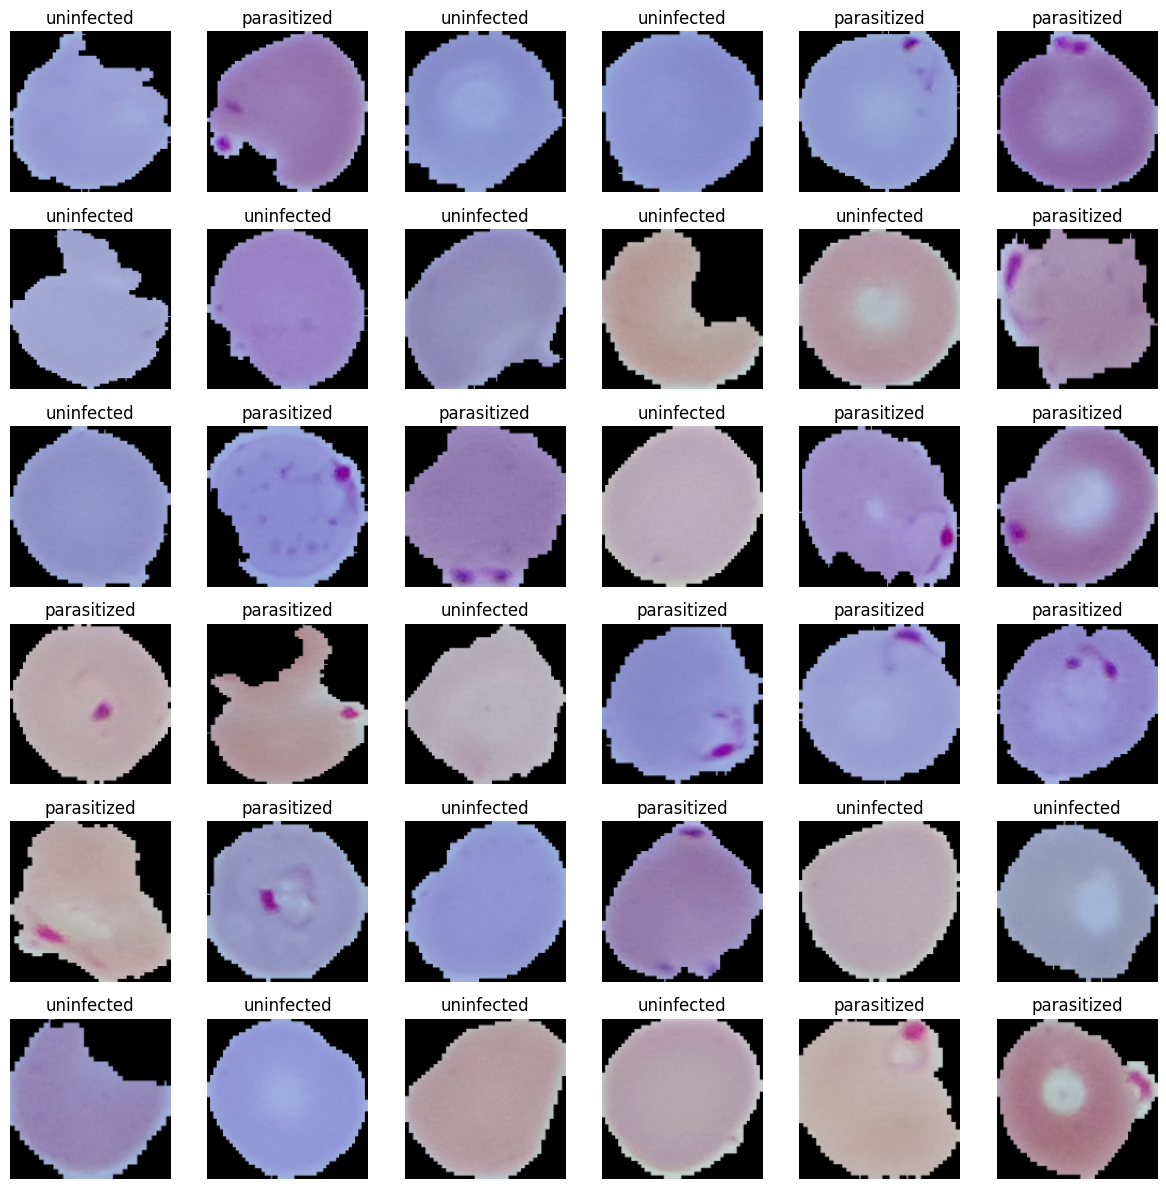

In [13]:
plt.figure(figsize=(12,12))

for i in range(36):
  plt.subplot(6, 6, i+1)
  plt.imshow(x_train[i])
  plt.title(y_train.loc[i,"Label"])
  plt.axis('off')

plt.tight_layout()
plt.show()

#### <b>Observations and insights:

### <b> Plotting the mean images for parasitized and uninfected

<b> Mean image for parasitized

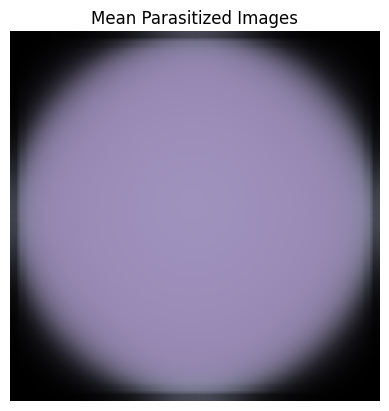

In [14]:
infected_indices = np.where(y_train["Label"] == 'parasitized')[0]
mean_infected = np.mean(x_train[infected_indices], axis=0)
plt.imshow(mean_infected)
plt.title("Mean Parasitized Images")
plt.axis("off")
plt.show()

<b> Mean image for uninfected

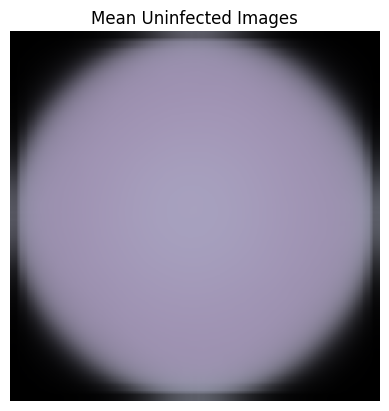

In [15]:
uninfected_indices = np.where(y_train["Label"] == 'uninfected')[0]
mean_uninfected = np.mean(x_train[uninfected_indices], axis=0)
plt.imshow(mean_uninfected)
plt.title("Mean Uninfected Images")
plt.axis("off")
plt.show()


#### <b> Observations and insights: _____

### <b>Converting RGB to HSV of Images using OpenCV

### <b> Converting the train data

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..240.0].


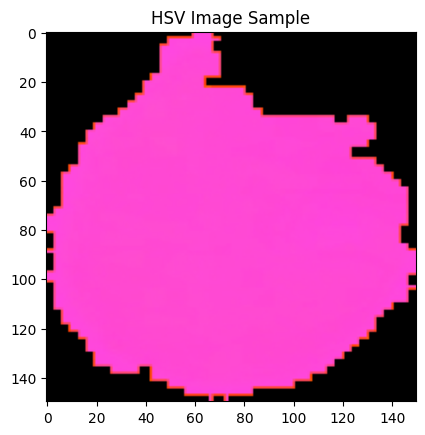

In [16]:
x_train_HSV = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2HSV) for img in x_train])

# visualizing one HSV image
plt.imshow(x_train_HSV[0])
plt.title("HSV Image Sample")
plt.show()

### <b> Converting the test data

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..242.03389].


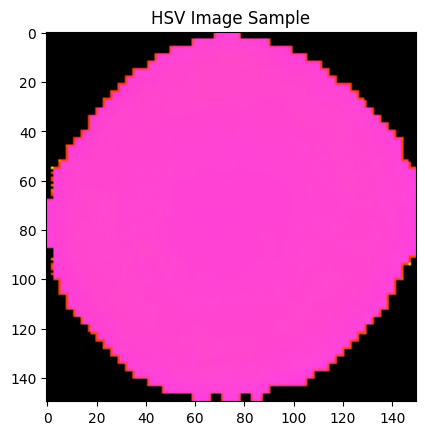

In [17]:
x_test_HSV = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2HSV) for img in x_test])

# visualizing one HSV image
plt.imshow(x_test_HSV[0])
plt.title("HSV Image Sample")
plt.show()

#### <b>Observations and insights: _____

### <b> Processing Images using Gaussian Blurring

### <b> Gaussian Blurring on train data

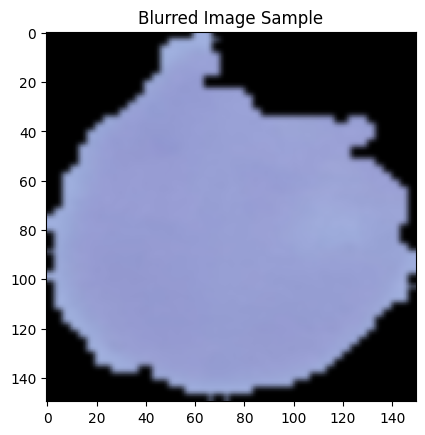

In [18]:
x_train_Blur = np.array([cv2.GaussianBlur(img, (5,5), 0) for img in x_train])

# visualizing one blur image
plt.imshow(x_train_Blur[0])
plt.title("Blurred Image Sample")
plt.show()

### <b> Gaussian Blurring on test data

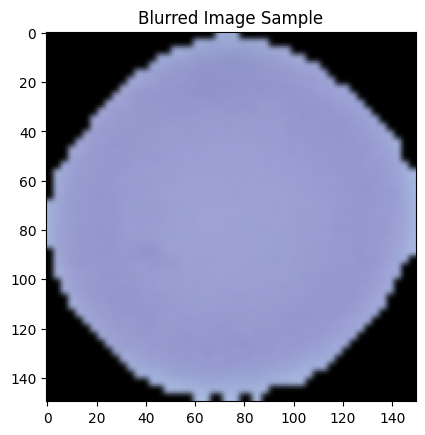

In [19]:
x_test_Blur = np.array([cv2.GaussianBlur(img, (5,5), 0) for img in x_test])

# visualizing one blur image
plt.imshow(x_test_Blur[0])
plt.title("Blurred Image Sample")
plt.show()

#### **Observations and insights: _____**

**Think About It:** Would blurring help us for this problem statement in any way? What else can we try?

In [20]:
%whos

Variable              Type         Data/Info
--------------------------------------------
categories            list         n=2
cv2                   module       <module 'cv2' from '/usr/<...>ackages/cv2/__init__.py'>
features              ndarray      150x150x3: 67500 elems, type `uint8`, 67500 bytes
i                     int          35
img_size              int          150
infected_indices      ndarray      12582: 12582 elems, type `int64`, 100656 bytes (98.296875 kb)
label                 str          uninfected
load_test_data        function     <function load_test_data at 0x7eae8ab74b80>
load_train_data       function     <function load_train_data at 0x7eae3bfc7060>
mean_infected         ndarray      150x150x3: 67500 elems, type `float32`, 270000 bytes (263.671875 kb)
mean_uninfected       ndarray      150x150x3: 67500 elems, type `float32`, 270000 bytes (263.671875 kb)
np                    module       <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
os               

In [21]:
del train_data, test_data, x_train_Blur, x_test_Blur, x_train_HSV, x_test_HSV

## **Model Building**

### **Base Model**




### <b> Importing the required libraries for building and training our Model

In [22]:
import tensorflow as tf

from tensorflow.keras import backend
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.utils import to_categorical
backend.clear_session()

2026-04-07 23:02:06.703405: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775602926.925042      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775602926.995604      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775602927.542740      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775602927.542768      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775602927.542771      24 computation_placer.cc:177] computation placer alr

#### <B>One Hot Encoding the train and test labels

In [23]:
y_train_encoded = (y_train["Label"] != "uninfected").astype(int)            # parasitized: 1, uninfected: 0
y_test_encoded  = (y_test["Label"]  != "uninfected").astype(int)

y_train_encoded = to_categorical(y_train_encoded, 2)
y_test_encoded  = to_categorical(y_test_encoded, 2)


### <b> Building the model

In [24]:
import random

backend.clear_session()

# Fixing the seed for random number generators so that we 
## can ensure we receive the same output everytime
np.random.seed(42)

random.seed(42)
tf.random.set_seed(42)

In [25]:
# initialinzing a sequential model
model = Sequential()

# first convolution layer with 32 filters and kernel size 3x3, padding 'same' provides the output size same as the input size
# The input_shape denotes input image dimension
model.add(Conv2D(32, (3,3), activation='relu', padding='same', 
                input_shape=(150, 150, 3)))

# max pooling to reduce the size of output of first conv layer
model.add(MaxPooling2D((2,2), padding='same'))

# second conv layer with 64 filters and kernel size 3x3, padding 'same' followed by a Maxpooling2D layer
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2), padding='same'))

# flatten the output of the conv layer after max pooling to make it ready for creating dense connections
model.add(Flatten())

# add a fully connected dense layer with 100 neurons
model.add(Dense(64,activation='relu'))

# add a dropout
model.add(Dropout(0.5))

# add the output layer with 2 neurons and activation functions as softmax since this is a multi-class classification problem
model.add(Dense(2, activation = 'softmax'))

I0000 00:00:1775602953.409272      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775602953.411076      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 92416)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,914,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,934,210 (22.64 MB)

 Trainable params: 5,934,210 (22.64 MB)

 Non-trainable params: 0 (0.00 B)

### <b> Compiling the model

In [27]:
model.compile(optimizer='adam', 
             loss='categorical_crossentropy',
             metrics=['accuracy'])

<b> Using Callbacks

In [28]:
# The following lines of code saves the best model's parameters if training accuracy goes down on further training
es = EarlyStopping(monitor = 'val_loss', mode = 'min', verbose = 1, patience = 5)
mc = ModelCheckpoint('best_model.h5', monitor = 'val_accuracy', mode = 'max', verbose = 1, save_best_only = True)

<b> Fit and train our Model

In [29]:
# Fitting the model with 15 epochs and validation_split as 20%
history = model.fit(x_train,
                   y_train_encoded,
                   epochs=15,
                   batch_size=16, validation_split=0.20,
                   callbacks=[es,mc],
                   verbose=1)

Epoch 1/15


I0000 00:00:1775602968.522753      75 service.cc:152] XLA service 0x7eacd400b050 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775602968.522784      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775602968.522790      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775602968.869575      75 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-07 23:02:50.393604: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 23:02:50.537453: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  16/1248 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4996 - loss: 0.8465

I0000 00:00:1775602972.312059      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1245/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7035 - loss: 0.5665

...

1248/1248 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9053 - loss: 0.2986 - val_accuracy: 0.9545 - val_loss: 0.1497
Epoch 3/15
1245/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9490 - loss: 0.1665
Epoch 3: val_accuracy improved from 0.95453 to 0.96054, saving model to best_model.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9490 - loss: 0.1665 - val_accuracy: 0.9605 - val_loss: 0.1348
Epoch 4/15
1244/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9564 - loss: 0.1451
Epoch 4: val_accuracy did not improve from 0.96054
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9564 - loss: 0.1451 - val_accuracy: 0.9545 - val_loss: 0.1591
Epoch 5/15
1246/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9606 - loss: 0.1230
Epoch 5: val_accuracy improved from 0.96054 to 0.96074, saving model to best_model.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9606 - loss: 0.1230 - val_accuracy: 0.9607 - val_loss: 0.1275
Epoch 6/15
1244/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9633 - loss: 0.1147
Epoch 6: val_accuracy improved from 0.96074 to 0.96274, saving model to best_model.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9633 - loss: 0.1147 - val_accuracy: 0.9627 - val_loss: 0.1150
Epoch 7/15
1244/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9629 - loss: 0.1098
Epoch 7: val_accuracy improved from 0.96274 to 0.96755, saving model to best_model.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9629 - loss: 0.1098 - val_accuracy: 0.9675 - val_loss: 0.1255
Epoch 8/15
1245/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9638 - loss: 0.1172
Epoch 8: val_accuracy did not improve from 0.96755
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9638 - loss: 0.1172 - val_accuracy: 0.9657 - val_loss: 0.1341
Epoch 9/15
1244/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9725 - loss: 0.0838
Epoch 9: val_accuracy did not improve from 0.96755
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9725 - loss: 0.0839 - val_accuracy: 0.9577 - val_loss: 0.1490
Epoch 10/15
1244/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9715 - loss: 0.0908
Epoch 10: val_accuracy did not improve from 0.96755
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9715 - loss: 0.0908 - val_accuracy: 0.9673 - val_loss: 0.1359
Epoch 11/15
1245/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9781 - loss: 0.0715
Epoc

### <b> Evaluating the model on test data

In [30]:
model.evaluate(x_test, (y_test_encoded))

82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9613 - loss: 0.1285


[0.1435328722000122, 0.9630769491195679]

<b> Plotting the confusion matrix

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1300
           1       0.97      0.95      0.96      1300

    accuracy                           0.96      2600
   macro avg       0.96      0.96      0.96      2600
weighted avg       0.96      0.96      0.96      2600



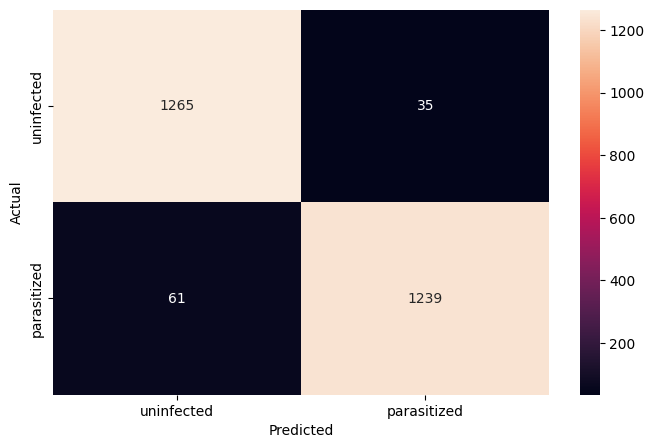

In [31]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

pred = model.predict(x_test)
pred = np.argmax(pred, axis = 1)
y_true = np.argmax(y_test_encoded, axis = 1)

# Printing the classification report
print(classification_report(y_true, pred))

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)
plt.figure(figsize = (8, 5))
sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = ["uninfected", "parasitized"], yticklabels=["uninfected", "parasitized"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

<b>Plotting the train and validation curves

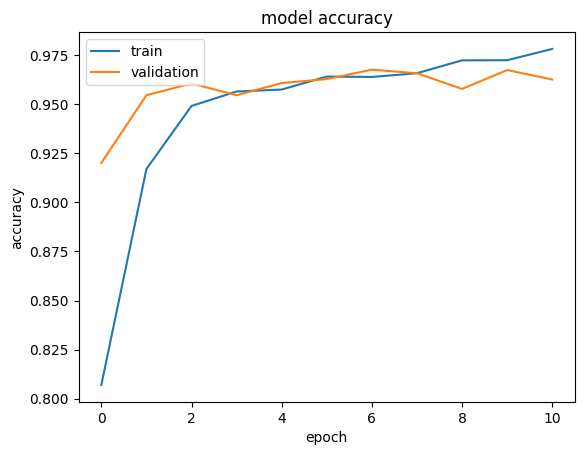

In [32]:
# Plotting the training and validation accuracies for each epoch

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

So now let's try to build another model with few more add on layers and try to check if we can try to improve the model. Therefore try to build a model by adding few layers if required and altering the activation functions.

### <b> Model 1
#### <b> Trying to improve the performance of our model by adding new layers


### <b> Building the Model

### <b> Compiling the model

<b> Using Callbacks

<b>Fit and Train the model

### <b> Evaluating the model

<b> Plotting the confusion matrix

<b> Plotting the train and the validation curves

### <b>Think about it:</b><br>
Now let's build a model with LeakyRelu as the activation function  

*  Can the model performance be improved if we change our activation function to LeakyRelu?
*  Can BatchNormalization improve our model?

Let us try to build a model using BatchNormalization and using LeakyRelu as our activation function.

### <b> Model 2 with Batch Normalization

### <b> Building the Model

### <b>Compiling the model

<b> Using callbacks

<b>Fit and train the model

<b>Plotting the train and validation accuracy

### <b>Evaluating the model

#### <b>Observations and insights: ____

<b> Generate the classification report and confusion matrix

### **Think About It :**<br>

* Can we improve the model with Image Data Augmentation?
* References to image data augmentation can be seen below:
  *   [Image Augmentation for Computer Vision](https://www.mygreatlearning.com/blog/understanding-data-augmentation/)
  *   [How to Configure Image Data Augmentation in Keras?](https://machinelearningmastery.com/how-to-configure-image-data-augmentation-when-training-deep-learning-neural-networks/)





### <b>Model 3 with Data Augmentation

### <b> Use image data generator

### **Think About It :**<br>

*  Check if the performance of the model can be improved by changing different parameters in the ImageDataGenerator.



#### <B>Visualizing Augmented images

#### <b>Observations and insights: ____

### <b>Building the Model

<b>Using Callbacks

<b> Fit and Train the model

### <B>Evaluating the model

<b>Plot the train and validation accuracy

<B>Plotting the classification report and confusion matrix

<b> Now, let us try to use a pretrained model like VGG16 and check how it performs on our data.

### **Pre-trained model (VGG16)**
- Import VGG16 network upto any layer you choose
- Add Fully Connected Layers on top of it

### <b>Compiling the model

<b> using callbacks

<b>Fit and Train the model

<b>Plot the train and validation accuracy

### **Observations and insights: _____**

*   What can be observed from the validation and train curves?

### <b> Evaluating the model

<b>Plotting the classification report and confusion matrix

### <b>Think about it:</b>
*  What observations and insights can be drawn from the confusion matrix and classification report?
*  Choose the model with the best accuracy scores from all the above models and save it as a final model.


#### <b> Observations and Conclusions drawn from the final model: _____



**Improvements that can be done:**<br>


*  Can the model performance be improved using other pre-trained models or different CNN architecture?
*  You can try to build a model using these HSV images and compare them with your other models.

#### **Insights**

#### **Refined insights**:
- What are the most meaningful insights from the data relevant to the problem?

#### **Comparison of various techniques and their relative performance**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

#### **Proposal for the final solution design**:
- What model do you propose to be adopted? Why is this the best solution to adopt?